**Problem 1**: Suppose we are given two finite sets $A$ and $B$, each consisting of real numbers. We are also given a mapping between them like this:
<div align="center">

| $A$ | $B$ |
|:-----:|:-----:|
| $2$     | $5$     |
| $2.5 $  | $6$     |
| $4$     | $9$     |
| $\ldots$   | $\ldots$   |

</div>


How can we construct a machine that learns (or approximates) the function $f: A \rightarrow B$?


Let's approach this methodically. We have two sets and a mapping. For simplicity's sake, let's assume $f$ is bijective. As a human, we can see that this mapping is:
$$f(x) = 2x + 1$$
In real applications, we'll take a dataset from somewhere and work with it. Now for this problem, we will try to synthesise the data for the machine to understand. So first, we need:

In [1]:
import torch

x = torch.linspace(-10, 10, 100).unsqueeze(1)

This means we're generating 100 numbers, evenly spaced from $-10$ to $10$, as a $1D$ tensor. Using `unsqueeze(1)` means that we're changing the shape of the tensor from a $1D$ tensor to a $2D$ tensor with one column. This is just for the machine to understand the data it's working with.

Next, we need a way for the machine to practice, an environment for it to try to mess around with the data and infer. We also need to pair this with a way for it to know if it's wrong, and how wrong it is. After we've quantified this error, we will feed this error to an optimiser to minimise that error through each learning step so that it can try to mess around with the data again. This process is repeated until the model has learnt the mapping.

Let's try with the most basic functions in pytorch. The simplest model is a single neuron, which implements a linear function. We define the model to be:
$$ \hat{y} = wx +b$$
The machine now has two parameters, $w$ and $b$ to tune. Next, we measure the error using a **loss function**, and one of the most simple statistical tools to do so is by using the **Mean Square Error** of the data set:
$$ L = \dfrac{1}{n}\sum_i (\hat{y}_i - y_i)^2$$
Because errors are squared, it heavily penalizes large mistakes. And lastly, we feed everything through an optimiser. We can use **Stochastic Gradient Descent**:
$$ \theta_{t+1} = \theta_{t} - \eta . \nabla L(\theta_t, x_i, y_i)$$
This means that the new parameters are calculated by the previous set of parameters minus the learning rate times the gradient of the function at the previous parameters and values. Basically, at each training step, the optimiser updates the model parameters by moving them in the direction that most decreases the loss. The learning rate determines how large each update is. We aim to minimise the loss function, or, trying to make the error as close to zero as possible.

Then, we just repeatedly run this loop through a number of **epochs**, which are training loops. An epoch is one complete pass through the training dataset. The code is as follows:

Weight: 2.0
Bias: 0.9999986290931702


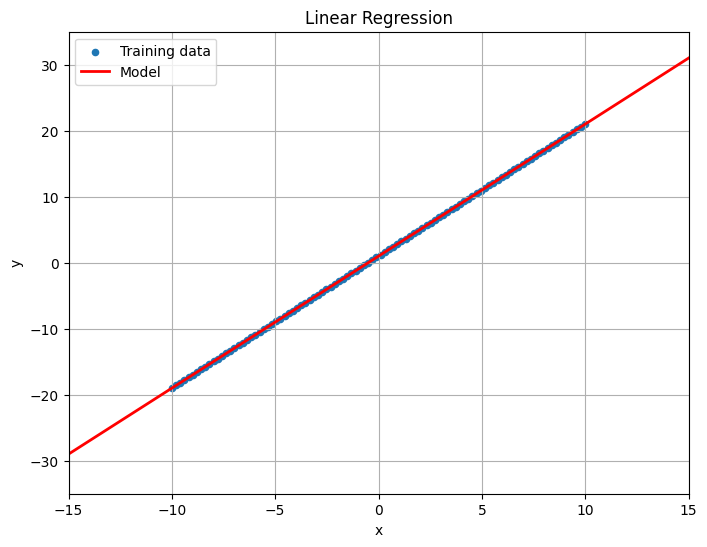

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Dataset
x = torch.linspace(-10, 10, 100).unsqueeze(1) 
y = 2 * x + 1

# Model
model = nn.Linear(1, 1)

# Loss
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    pred = model(x)
    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

# -------------------------
# Plot
# -------------------------

xmin, xmax = -15, 15

# Points to evaluate the model on
x_plot = torch.linspace(xmin, xmax, 200).unsqueeze(1)

# Disable gradient tracking during inference
with torch.no_grad():
    y_plot = model(x_plot)

plt.figure(figsize=(8, 6))

# Original data
plt.scatter(x.numpy(), y.numpy(), label="Training data", s=20)

# Learned model
plt.plot(x_plot.numpy(), y_plot.numpy(),
         color="red", linewidth=2, label="Model")

plt.xlim(xmin, xmax)
plt.ylim(-35, 35)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.grid(True)
plt.legend()

plt.show()

We can try changing the model to any linear function $y = ax +b$ and our one neuron would be able to learn it. Since the true mapping is linear, a single neuron has exactly the expressive power required to represent it. Given sufficient training, it can recover the exact parameters $w=2$ and $b=1$.

And when we add noise, we gain the line of best fit:

Weight: 1.9959537982940674
Bias: 1.2067596912384033


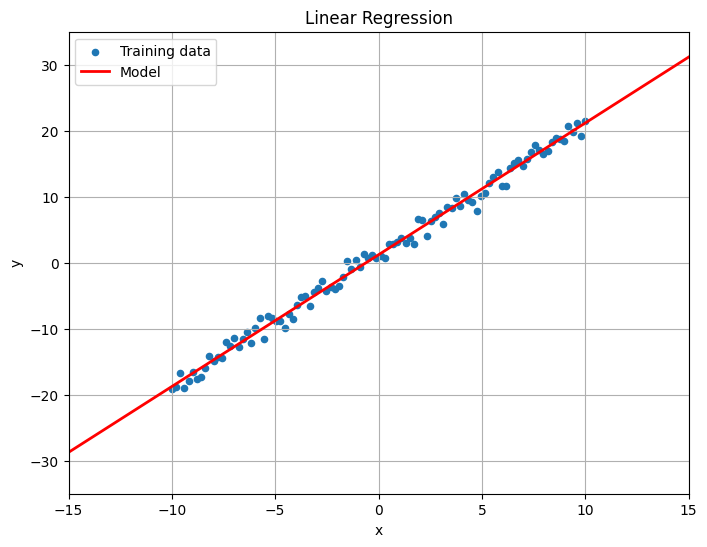

In [3]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Dataset
x = torch.linspace(-10, 10, 100).unsqueeze(1) 
y = 2 * x + 1 + torch.randn_like(x)

# Model
model = nn.Linear(1, 1)

# Loss
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    pred = model(x)
    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

# -------------------------
# Plot
# -------------------------

xmin, xmax = -15, 15

# Points to evaluate the model on
x_plot = torch.linspace(xmin, xmax, 200).unsqueeze(1)

# Disable gradient tracking during inference
with torch.no_grad():
    y_plot = model(x_plot)

plt.figure(figsize=(8, 6))

# Original data
plt.scatter(x.numpy(), y.numpy(), label="Training data", s=20)

# Learned model
plt.plot(x_plot.numpy(), y_plot.numpy(),
         color="red", linewidth=2, label="Model")

plt.xlim(xmin, xmax)
plt.ylim(-35, 35)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.grid(True)
plt.legend()

plt.show()

Real-world measurements are rarely exact. By adding Gaussian noise to the outputs, the data no longer lies perfectly on a line. The model can no longer recover the exact mapping, but instead learns the line that minimises the mean squared error, the familiar least-squares line of best fit.

Multivariate linear regression using the least squares method works the same way. To wrap this using pytorch, we simply change the dimensions. Now suppose our function is any general matrix equation:
$$ f(\mathbf{x}) = \mathbf{Ax+b}$$
where $\mathbf{A} \in \mathbb{R}^{m \times n}$, $\mathbf{b} \in \mathbb{R}^m$, and $\mathbf{x} \in \mathbb{R}^n$. We only change the dimensions in pytorch functions:

In [4]:
import torch
import torch.nn as nn

# Dataset
# 100 random 2D points
x = torch.rand(100, 2) * 20 - 10   

A = torch.tensor([
    [2.0, -1.0],
    [0.5, 3.0]
])

b = torch.tensor([1.0, -2.0])

y = x @ A.T + b

# Model
model = nn.Linear(2, 2)

# Loss
criterion = nn.MSELoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Training loop
for epoch in range(1000):
    pred = model(x)
    loss = criterion(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print("Weight:", model.weight)
print("Bias:", model.bias)

Weight: Parameter containing:
tensor([[ 2.0000, -1.0000],
        [ 0.5000,  3.0000]], requires_grad=True)
Bias: Parameter containing:
tensor([ 0.9999, -1.9999], requires_grad=True)


At this point, it is worth noting that there is little distinction between classical linear regression and machine learning in this setting. Our model consists of a single linear transformation with learnable parameters, the loss function is the familiar mean squared error, and the optimiser simply adjusts the parameters to minimise this error. In fact, `nn.Linear` with `MSELoss` is mathematically equivalent to ordinary least-squares linear regression; the only difference is that PyTorch learns the parameters iteratively using gradient descent rather than solving the least-squares problem directly. Both approaches ultimately recover the same linear mapping, provided the optimisation converges. This common foundation is important, because modern neural networks are built by stacking and composing these same linear layers together with nonlinear activation functions. Understanding linear regression in PyTorch therefore provides the conceptual bridge from classical statistical learning to deep learning. 

So for now, with $f$ being a affine mapping, we can say: **problem solved**.